In [4]:
"""
Created on Tue Mar 12 20:45:42 2024

@author: Anne
"""



import os.path
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta
from datetime import datetime
import time
from time import process_time
import calendar
import holidays
from pathlib import Path


Blue1 = (0.341, 0.82, 1)
Blue2 = (0.341, 0.592, 1)
Blue3 = (0.365, 0.365, 1)
Blue4 = (0, 0, 0.89)
Blue5 = (0, 0, 0.639)
Blue6 = (0, 0.161, 0.42)

Red1 = (1, 0.725, 0.635)
Red2 = (1, 0.6, 0.467)
Red3 = (1, 0.361, 0.353)
Red4 = (1, 0.153, 0.137)
Red5 = (0.812, 0.016, 0)
Red6 = (0.541, 0.008, 0)


#################################################################################
# Parameters
#################################################################################


dt_m_EV = 15
dt_h = dt_m_EV/60
interval = timedelta(minutes=dt_m_EV)        
unit = dt_h


# Energy Prices-AL-TOU:

# Summer: off-peak period energy charge rate $0.10679/kW h
#         On-peak period energy charge rate $0.12628/kW h
# Winter: off-peak period energy charge rate $0.09506/kW h
#         On-peak period energy charge rate $0.10626/kW h
c_e_TOU_AL = np.ones((96, 1))*0.10679
c_e_TOU_AL[16*4:21*4] = 0.12628


# Demand Charges
c_NCD = 24.48
c_PD = 19.14 + 9.78

# Tax
c_tax_DWR = 0.00580                               # x Total kWh
c_tax_oEESbo_Franchise = 0.0688 * c_tax_DWR       # x Total kWh
c_tax_CA_Surcharge = 0.00030                      # x Total kWh
c_tax_CA_Regulatory = 0.00058                     # x Total kWh
# x Total Bill (UDC+Commodity)
c_tax_SD_Franchise = 0.0578

c_tax_all = c_tax_DWR + c_tax_oEESbo_Franchise + c_tax_CA_Surcharge + c_tax_CA_Regulatory


#################################################################################
# Different service level during ELRP hours
#################################################################################


x = [1, 0.8, 0.6, 0.4, 0.2, 0]

# manual type in real ELRP event days in year 2022
ELRP_2022 = [datetime(2022, 8, 31), datetime(2022, 9, 1), datetime(2022, 9, 3), \
             datetime(2022, 9, 4), datetime(2022, 9, 5),  datetime(2022, 9, 6), \
             datetime(2022, 9, 7), datetime(2022, 9, 8),  datetime(2022, 9, 9)]


#Holidays = [datetime(2022, 9, 5)]
Holidays = holidays.US()







#################################################################################
# Choose the 'Date' and forecast you want to analyze
#################################################################################


Forecast = 'Persistence'  # 'Perfect' #'Persistence'

year = 2022
month = 12



Fc_SessionkWh = 'PerfectSessionkWh'  # 'PerfectSessionkWh' #'PersistenceSessionkWh'
Fc_NumbEV = 'PerfectNumbEV'          # 'PerfectNumbEV'     #'PersistenceNumbEV'
Fc_AtArrival = 'PerfectatArrival'    # 'PerfectatArrival'  #'MLatArrival'


   
#################################################################################
# Daily Stair plot
#################################################################################  

  
#kWh data fron saved data
dir_Input = os.path.join( '/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/2024_RO3.4/Results/Tables/Dispatch' )
filename_Input = dir_Input + '/2022_'+Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'_MonthlyTh_Eta_v5_test4.csv'
Dispatch_2022 = pd.read_csv(filename_Input, index_col=None)

Dispatch_2022['Interval start'] = pd.to_datetime(Dispatch_2022['Interval start'])
Dispatch_2022 = Dispatch_2022.drop_duplicates('Interval start',keep='last') 

start_ind = datetime(year, month, 1, 0, 0, 0)
end_ind = start_ind + timedelta(days=int(1))
num_days = 1
start_D = start_ind
end_D   = end_ind

TimeSeries_ThisDate_real = []
while start_ind < end_ind:
    TimeSeries_ThisDate_real.append(start_ind)
    start_ind += interval

Dispatch_2022_ThisD = Dispatch_2022[(Dispatch_2022['Interval start']>=start_D)&(Dispatch_2022['Interval start']<end_D)]
Dispatch_2022_ThisD = Dispatch_2022_ThisD.reset_index() 

t1 = TimeSeries_ThisDate_real.copy()
t2 = TimeSeries_ThisDate_real.copy()
t2.append(TimeSeries_ThisDate_real[-1] + timedelta(minutes=dt_m_EV))

t3 = t2[0:2]

    
xmin = t2[0]
xmax = t2[-1]
ymin = -3
ymax = 105 #203

# create a list of kWh time series for 9 scenarios: V0G, V1Greal, V1Goffline, V1G10, V1G08, V1G06, V1G04, V1G02, V1G00    

D_data = [np.array(Dispatch_2022_ThisD['V0G [kWh]']).reshape(96*num_days,1), \
         np.array(Dispatch_2022_ThisD['V1G_real [kWh]']).reshape(96*num_days,1), \
         np.array(Dispatch_2022_ThisD['Opt_DA [kWh]']).reshape(96*num_days,1),\
         np.array(Dispatch_2022_ThisD['Opt_RT_t0 [kWh]']).reshape(96*num_days,1),\
         np.array(Dispatch_2022_ThisD['Base [kWh]']).reshape(96*num_days,1),\
         np.array(Dispatch_2022_ThisD['Case1 [kWh]']).reshape(96*num_days,1),\
         np.array(Dispatch_2022_ThisD['baseline_Base']).reshape(96*num_days,1),\
         np.array(Dispatch_2022_ThisD['baseline_Case1']).reshape(96*num_days,1),\
         np.array(Dispatch_2022_ThisD['NCD_Base']).reshape(96*num_days,1),\
         np.array(Dispatch_2022_ThisD['PD_Base']).reshape(96*num_days,1),\
         np.array(Dispatch_2022_ThisD['NCD_Case1']).reshape(96*num_days,1),\
         np.array(Dispatch_2022_ThisD['PD_Case1']).reshape(96*num_days,1),\
         np.array(Dispatch_2022_ThisD['LMP_DA']).reshape(96*num_days,1),\
         np.array(Dispatch_2022_ThisD['LMP_RT']).reshape(96*num_days,1),\
         np.array(Dispatch_2022_ThisD['event hour_Base']).reshape(96*num_days,1),\
         np.array(Dispatch_2022_ThisD['event hour_Case1']).reshape(96*num_days,1)]


# columns = [col for col in Dispatch_2022_ThisD.columns if col != 'interval']
# D_data = [np.array(Dispatch_2022_ThisD[col]).reshape(96*num_days, 1) for col in columns]


/var/folders/pj/537pcfgn4672xs4gjs0w444w0000gn/T/ipykernel_78470/3851140676.py:56: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([Baseline_100, Baseline_Eta, Opt_DA, Opt_t0, \


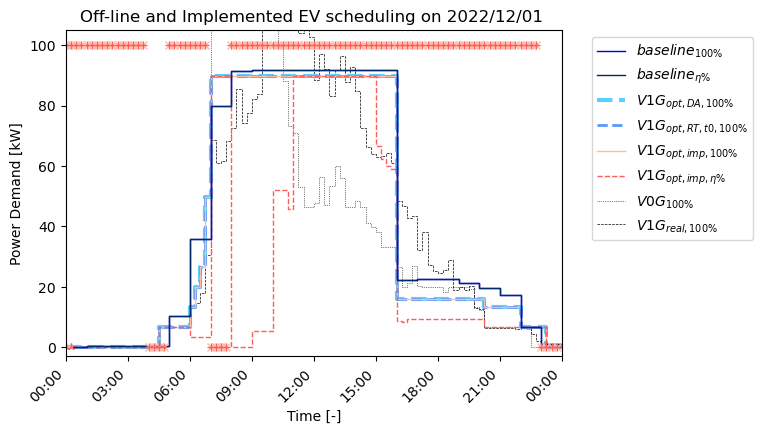

In [5]:
    

Pw_V0G          = pd.Series((D_data[0]/unit).reshape(96))
Pw_V1G          = pd.Series((D_data[1]/unit).reshape(96))
Pw_Opt_DA       = pd.Series((D_data[2]/unit).reshape(96))
Pw_Opt_RT_t0    = pd.Series((D_data[3]/unit).reshape(96))
Pw_Opt_Imp_100  = pd.Series((D_data[4]/unit).reshape(96))
Pw_Opt_Imp_Eta  = pd.Series((D_data[5]/unit).reshape(96))
Pw_Baseline_100 = pd.Series((D_data[6]/unit).reshape(96))
Pw_Baseline_Eta = pd.Series((D_data[7]/unit).reshape(96))


Pw_V0G_stair          = pd.concat([pd.Series(Pw_V0G[0])         ,Pw_V0G])
Pw_V1G_stair          = pd.concat([pd.Series(Pw_V1G[0])         ,Pw_V1G])
Pw_Opt_DA_stair       = pd.concat([pd.Series(Pw_Opt_DA[0])      ,Pw_Opt_DA])
Pw_Opt_RT_t0_stair    = pd.concat([pd.Series(Pw_Opt_RT_t0[0])   ,Pw_Opt_RT_t0])
Pw_Opt_Imp_100_stair  = pd.concat([pd.Series(Pw_Opt_Imp_100[0]) ,Pw_Opt_Imp_100])
Pw_Opt_Imp_Eta_stair  = pd.concat([pd.Series(Pw_Opt_Imp_Eta[0]) ,Pw_Opt_Imp_Eta])
Pw_Baseline_100_stair = pd.concat([pd.Series(Pw_Baseline_100[0]),Pw_Baseline_100])
Pw_Baseline_Eta_stair = pd.concat([pd.Series(Pw_Baseline_Eta[0]),Pw_Baseline_Eta])


Event_100 = np.array(D_data[14])*100
Event_Eta = np.array(D_data[15])*100


Pw_NCD_100_stair = pd.concat([pd.Series(D_data[8][0]),pd.Series(D_data[8][0])])
Pw_NCD_Eta_stair = pd.concat([pd.Series(D_data[10][0]),pd.Series(D_data[10][0])])
Pw_PD_100_stair  = pd.concat([pd.Series(D_data[9][0]),pd.Series(D_data[9][0])])
Pw_PD_Eta_stair  = pd.concat([pd.Series(D_data[11][0]),pd.Series(D_data[11][0])]) 


plt.figure()
V0G,         = plt.step(t2, Pw_V0G_stair      , linestyle=':', color='k', linewidth=0.5)
V1G,         = plt.step(t2, Pw_V1G_stair          , linestyle='--', color='k', linewidth=0.5)
Opt_DA,      = plt.step(t2, Pw_Opt_DA_stair  , linestyle='--', color=Blue1, linewidth=3)
Opt_t0,      = plt.step(t2, Pw_Opt_RT_t0_stair       , linestyle='--', color=Blue2, linewidth=2) 
Opt_Imp_100, = plt.step(t2, Pw_Opt_Imp_100_stair , linestyle='-',  color=Red1, linewidth=1)
Opt_Imp_Eta, = plt.step(t2, Pw_Opt_Imp_Eta_stair, linestyle='--', color=Red3, linewidth=1)

Baseline_100 , = plt.step(t2, Pw_Baseline_100_stair , linestyle='-', color=Blue4 , linewidth=1)
Baseline_Eta, = plt.step(t2, Pw_Baseline_Eta_stair, linestyle='-', color=Blue6 , linewidth=1)

NCD_100 = plt.step(t3, Pw_NCD_100_stair, linestyle='-', color=Red1, linewidth=2)
NCD_Eta = plt.step(t3, Pw_NCD_Eta_stair, linestyle='', color=Red3, linewidth=0.5, marker='2')
PD_100  = plt.step(t3, Pw_PD_100_stair , linestyle='-', color=Red1, linewidth=2)
PD_Eta  = plt.step(t3, Pw_PD_Eta_stair , linestyle='', color=Red3, linewidth=0.5, marker='2')       

Event_100_ = plt.plot(t1, Event_100, linestyle='', color=Red1, linewidth=0.5, marker='x')  
Event_Eta_ = plt.plot(t1, Event_Eta, linestyle='', color=Red3, linewidth=0.5, marker='+') 

 
plt.title("Off-line and Implemented EV scheduling on " + start_D.strftime("%Y/%m/%d "))
plt.xlabel('Time [-]')
plt.ylabel('Power Demand [kW]') 

    
plt.legend([Baseline_100, Baseline_Eta, Opt_DA, Opt_t0, \
            Opt_Imp_100, Opt_Imp_Eta, V0G, V1G,\
            NCD_100, NCD_Eta, PD_100, PD_Eta,\
            Event_100_,  Event_Eta_ ],\
           [r'$baseline_{100\%}$'   ,   r'$baseline_{\eta\%}$'  , r'$V1G_{opt,DA,100\%}$', r'$V1G_{opt,RT,t0,100\%}$',\
            r'$V1G_{opt,imp,100\%}$', r'$V1G_{opt,imp,\eta \%}$', r'$V0G_{100\%}$',   r'$V1G_{real,100\%}$',\
            r'$NCD_{opt,imp,100\%}$', r'$NCD_{opt,imp,\eta \%}$', r'$PD_{opt,imp,100\%}$', r'$PD_{opt,imp,\eta \%}$',\
            r'$event hour_{opt,imp,100\%}$', r'$event hour_{opt,imp,\eta \%}$'    ],\
            bbox_to_anchor=(1.4, 1.0))    
            

    
# beautify the x-labels
plt.gcf().autofmt_xdate()
myFmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)
plt.xticks(rotation=45)
plt.xlim(xmin, xmax)
#plt.ylim(ymin, ymax_pw)
plt.ylim(ymin, ymax)
#plt.xlim(xmin_ZoomIn, xmax_ZoomIn)
#plt.ylim(ymin_ZoomIn, ymax_ZoomIn)    
if Forecast == 'Perfect':
    FC = 'PerfectFc'
else:
    FC = 'PersistenceFc'

# =============================================================================
# path = 'C:/Users/Anne/Desktop/Total/Results/Plots/Flexibility/Results8_5_4_'+ start_D.strftime("%Y")+'/'+FC+'/'
# plt.savefig(path  + start_D.strftime("%Y%m%d") + '_Implemented_Pw_stair.pdf', bbox_inches='tight')               
# =============================================================================
#plt.rcParams.update({'font.size': 15})
plt.show()




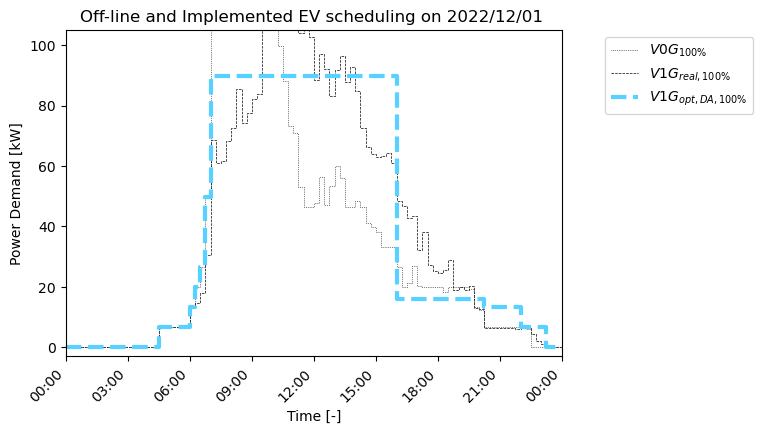

/var/folders/pj/537pcfgn4672xs4gjs0w444w0000gn/T/ipykernel_78470/117558391.py:56: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([Baseline_100, Opt_DA, Opt_t0, \


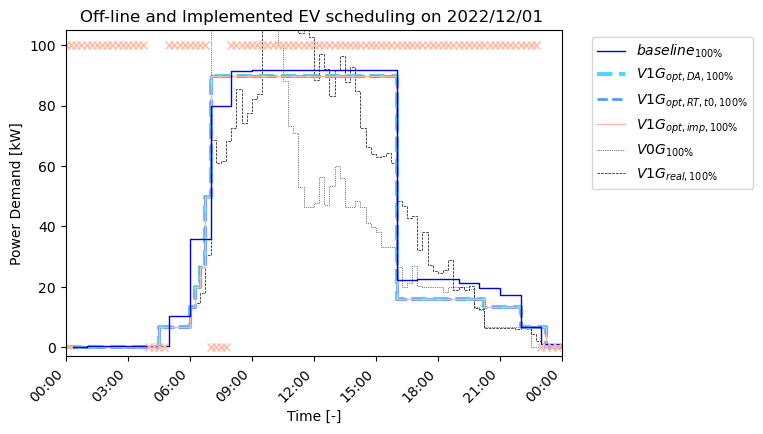

In [6]:
#################################################################################
# Step by step plots
#################################################################################  


plt.figure()
V0G,         = plt.step(t2, Pw_V0G_stair      , linestyle=':', color='k', linewidth=0.5)
V1G,         = plt.step(t2, Pw_V1G_stair          , linestyle='--', color='k', linewidth=0.5)
Opt_DA,      = plt.step(t2, Pw_Opt_DA_stair  , linestyle='--', color=Blue1, linewidth=3)

    
plt.legend([V0G, V1G, Opt_DA],\
           [r'$V0G_{100\%}$',   r'$V1G_{real,100\%}$', r'$V1G_{opt,DA,100\%}$'],\
            bbox_to_anchor=(1.4, 1.0))    
            
    
# beautify the x-labels
plt.gcf().autofmt_xdate()
myFmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)
plt.xticks(rotation=45)
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.title("Off-line and Implemented EV scheduling on " + start_D.strftime("%Y/%m/%d "))
plt.xlabel('Time [-]')
plt.ylabel('Power Demand [kW]') 


plt.show()










plt.figure()
V0G,         = plt.step(t2, Pw_V0G_stair      , linestyle=':', color='k', linewidth=0.5)
V1G,         = plt.step(t2, Pw_V1G_stair          , linestyle='--', color='k', linewidth=0.5)
Opt_DA,      = plt.step(t2, Pw_Opt_DA_stair  , linestyle='--', color=Blue1, linewidth=3)
Opt_t0,      = plt.step(t2, Pw_Opt_RT_t0_stair       , linestyle='--', color=Blue2, linewidth=2) 
Opt_Imp_100, = plt.step(t2, Pw_Opt_Imp_100_stair , linestyle='-',  color=Red1, linewidth=1)
Baseline_100 , = plt.step(t2, Pw_Baseline_100_stair , linestyle='-', color=Blue4 , linewidth=1)

NCD_100 = plt.step(t3, Pw_NCD_100_stair, linestyle='-', color=Red1, linewidth=2)
PD_100  = plt.step(t3, Pw_PD_100_stair , linestyle='-', color=Red1, linewidth=2)
    

Event_100_ = plt.plot(t1, Event_100, linestyle='', color=Red1, linewidth=0.5, marker='x')  


plt.legend([Baseline_100, Opt_DA, Opt_t0, \
            Opt_Imp_100, V0G, V1G,\
            NCD_100, PD_100, \
            Event_100_],\
           [r'$baseline_{100\%}$'   ,   r'$V1G_{opt,DA,100\%}$', r'$V1G_{opt,RT,t0,100\%}$',\
            r'$V1G_{opt,imp,100\%}$', r'$V0G_{100\%}$',   r'$V1G_{real,100\%}$',\
            r'$NCD_{opt,imp,100\%}$', r'$PD_{opt,imp,100\%}$',\
            r'$event hour_{opt,imp,100\%}$'],\
            bbox_to_anchor=(1.4, 1.0))  

# beautify the x-labels
plt.gcf().autofmt_xdate()
myFmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)
plt.xticks(rotation=45)
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.title("Off-line and Implemented EV scheduling on " + start_D.strftime("%Y/%m/%d "))
plt.xlabel('Time [-]')
plt.ylabel('Power Demand [kW]') 


plt.show()


















In [7]:
#################################################################################
# Monthly stair plot 
#################################################################################   

    
    
start_ind = datetime(year, month, 1, 0, 0, 0)
num_days = calendar.monthrange(year,month)[1] 
end_ind = start_ind + timedelta(days=int(num_days))
start_M = start_ind
end_M   = end_ind

TimeSeries_ThisM = []
while start_ind < end_ind:
    TimeSeries_ThisM.append(start_ind)
    start_ind += interval



M_xmin_1 = pd.to_datetime(TimeSeries_ThisM[0])
M_xmax_1 = pd.to_datetime(TimeSeries_ThisM[959]+timedelta(minutes = dt_m_EV))  #09/10 23:45
M_xmin_2 = pd.to_datetime(TimeSeries_ThisM[959])
M_xmax_2 = pd.to_datetime(TimeSeries_ThisM[1919]+timedelta(minutes = dt_m_EV))  #09/20 23:45
M_xmin_3 = pd.to_datetime(TimeSeries_ThisM[1919])
M_xmax_3 = pd.to_datetime(TimeSeries_ThisM[-1]+timedelta(minutes = dt_m_EV))

M_xmin_list = [M_xmin_1,M_xmin_2,M_xmin_3]
M_xmax_list = [M_xmax_1,M_xmax_2,M_xmax_3]        
M_t2 = TimeSeries_ThisM.copy()
M_t2.append(TimeSeries_ThisM[-1] + timedelta(minutes=dt_m_EV))





Dispatch_2022_ThisM = Dispatch_2022[(Dispatch_2022['Interval start']>=start_M)&(Dispatch_2022['Interval start']<end_M)]
Dispatch_2022_ThisM = Dispatch_2022_ThisM.reset_index() 



M_Pw_V0G_max = Dispatch_2022_ThisM['V0G [kWh]']/unit
M_Pw_V1G = Dispatch_2022_ThisM['V1G_real [kWh]']/unit
M_Pw_Opt_Offline_10 = Dispatch_2022_ThisM['Opt_offline [kWh]']/unit
M_Pw_Opt_Implemented_10 = Dispatch_2022_ThisM['1 [kWh]']/unit
M_Pw_Opt_Implemented_08 =Dispatch_2022_ThisM['0.8 [kWh]']/unit
M_Pw_Opt_Implemented_06 = Dispatch_2022_ThisM['0.6 [kWh]']/unit
M_Pw_Opt_Implemented_04 = Dispatch_2022_ThisM['0.4 [kWh]']/unit
M_Pw_Opt_Implemented_02 = Dispatch_2022_ThisM['0.2 [kWh]']/unit
M_Pw_Opt_Implemented_00 = Dispatch_2022_ThisM['0 [kWh]']/unit
M_Pw_Baseline_Opt = pd.Series(Dispatch_2022_ThisM['Opt_base [kWh]']/unit)




M_Pw_V0G_max_stair            = pd.concat([pd.Series(M_Pw_V0G_max.iloc[0])           ,M_Pw_V0G_max])
M_Pw_V1G_stair                = pd.concat([pd.Series(M_Pw_V1G.iloc[0])               ,M_Pw_V1G])
M_Pw_Opt_Offline_10_stair     = pd.concat([pd.Series(M_Pw_Opt_Offline_10.iloc[0])    ,M_Pw_Opt_Offline_10])
M_Pw_Opt_Implemented_10_stair = pd.concat([pd.Series(M_Pw_Opt_Implemented_10.iloc[0]),M_Pw_Opt_Implemented_10])
M_Pw_Opt_Implemented_08_stair = pd.concat([pd.Series(M_Pw_Opt_Implemented_08.iloc[0]),M_Pw_Opt_Implemented_08])
M_Pw_Opt_Implemented_06_stair = pd.concat([pd.Series(M_Pw_Opt_Implemented_06.iloc[0]),M_Pw_Opt_Implemented_06])
M_Pw_Opt_Implemented_04_stair = pd.concat([pd.Series(M_Pw_Opt_Implemented_04.iloc[0]),M_Pw_Opt_Implemented_04])
M_Pw_Opt_Implemented_02_stair = pd.concat([pd.Series(M_Pw_Opt_Implemented_02.iloc[0]),M_Pw_Opt_Implemented_02])
M_Pw_Opt_Implemented_00_stair = pd.concat([pd.Series(M_Pw_Opt_Implemented_00.iloc[0]),M_Pw_Opt_Implemented_00])
M_Pw_Baseline_Opt_stair       = pd.concat([pd.Series(M_Pw_Baseline_Opt.iloc[0])     ,M_Pw_Baseline_Opt])
    
for i in range(3):
#i=2
    plt.figure(figsize=(13,6))  
        
    M_V0G_,               = plt.step(M_t2, M_Pw_V0G_max_stair           , linestyle=':', color='k', linewidth=1.5)
    M_V1G_,               = plt.step(M_t2, M_Pw_V1G_stair               , linestyle='--', color='k', linewidth=1.5)
    M_Opt_Offline_10,     = plt.step(M_t2, M_Pw_Opt_Offline_10_stair    , linestyle='--', color=Blue1, linewidth=2)
    M_Opt_Implemented_10, = plt.step(M_t2, M_Pw_Opt_Implemented_10_stair, linestyle='-',  color=Red1, linewidth=1)
    M_Opt_Implemented_08, = plt.step(M_t2, M_Pw_Opt_Implemented_08_stair, linestyle='--', color=Red2, linewidth=1)
    M_Opt_Implemented_06, = plt.step(M_t2, M_Pw_Opt_Implemented_06_stair, linestyle='--', color=Red3, linewidth=1)
    M_Opt_Implemented_04, = plt.step(M_t2, M_Pw_Opt_Implemented_04_stair, linestyle='--', color=Red4, linewidth=1)
    M_Opt_Implemented_02, = plt.step(M_t2, M_Pw_Opt_Implemented_02_stair, linestyle='--', color=Red5, linewidth=1)
    M_Opt_Implemented_00, = plt.step(M_t2, M_Pw_Opt_Implemented_00_stair, linestyle='--', color=Red6, linewidth=1)
    #M_Baseline_V0G_,      = plt.step(M_t2, M_Pw_Baseline_V0G_stair      , linestyle='-' , color='k' , linewidth=0.5)
    M_Baseline_Opt_,      = plt.step(M_t2, M_Pw_Baseline_Opt_stair      , linestyle='--', color=Blue4 , linewidth=1)        



    #plt.title("Off-line and Implemented EV scheduling " + H_Start_RT.strftime("%Y/%m "))
    plt.xlabel('Time [-]')
    plt.ylabel('Power Demand [kW]')
    plt.legend([M_V0G_, M_V1G_,       M_Opt_Offline_10,
                M_Opt_Implemented_10, M_Opt_Implemented_08, M_Opt_Implemented_06, \
                M_Opt_Implemented_04, M_Opt_Implemented_02, M_Opt_Implemented_00,\
                M_Baseline_Opt_],
               [r'$V0G_{100\%}$',                 r'$V1G_{real,100\%}$',                 r'$V1G_{opt,100\%,off}$',
                r'$V1G_{opt,100\%,imp}$', r'$V1G_{opt,80\%,imp}$', r'$V1G_{opt,60\%,imp}$',
                r'$V1G_{opt,40\%,imp}$',  r'$V1G_{opt,20\%,imp}$',  r'$V1G_{opt,0\%,imp}$',\
                r'$baseline_{opt}$' ],
               bbox_to_anchor=(1.05, 1.0), loc='upper left', ncol=1)    
        
    # beautify the x-labels
    plt.gcf().autofmt_xdate()
    myFmt = mdates.DateFormatter('%Y/%m/%d')
    plt.gca().xaxis.set_major_formatter(myFmt)
    plt.xticks(rotation=45)
    
    plt.xlim(M_xmin_list[i], M_xmax_list[i])
    plt.ylim(ymin, ymax_pw)
    #plt.rcParams.update({'font.size': 20})
    
    #save plot
    if Forecast == 'Perfect':
        FC = 'PerfectFc'
    else:
        FC = 'PersistenceFc'

# =============================================================================
#     path = 'C:/Users/Anne/Desktop/Total/Results/Plots/Flexibility/Results8_5_4_'+ start_M.strftime("%Y")+'/'+FC+'/'
#     plt.savefig(path  + start_M.strftime("%Y%m") + '_Implemented_Pw_stair_'+ str(i) +'.pdf', bbox_inches='tight')
# =============================================================================
    #plt.rcParams.update({'font.size': 28})
    plt.show()

KeyError: 'Opt_offline [kWh]'

In [ ]:
# =============================================================================
# fig, (ax0, ax1, ax2) = plt.subplots(3)
# plt.figure(figsize=(13,6)) 
# plt.rcParams.update({'font.size': 20})
# M_V0G_,               = ax0.step(M_t2, M_Pw_V0G_max_stair           , linestyle=':', color='k', linewidth=1.5)
# ax0.set_xlim(M_xmin_list[0], M_xmax_list[0])
# plt.setp(ax0.get_xticklabels(), rotation=30, ha='right')
# 
# 
# M_V0G_,               = ax1.step(M_t2, M_Pw_V0G_max_stair           , linestyle=':', color='k', linewidth=1.5)
# ax1.set_xlim(M_xmin_list[1], M_xmax_list[1])
# plt.setp(ax1.get_xticklabels(), rotation=30, ha='right')
# 
# 
# M_V0G_,               = ax2.step(M_t2, M_Pw_V0G_max_stair           , linestyle=':', color='k', linewidth=1.5)
# ax2.set_xlim(M_xmin_list[2], M_xmax_list[2])
# plt.setp(ax2.get_xticklabels(), rotation=30, ha='right')
# 
# 
# 
# plt.show()
# =============================================================================
        

# =============================================================================
# # beautify the x-labels
# all_axes = plt.gcf().get_axes()
# #ax = all_axes[0]
# all_axes[0].gcf().autofmt_xdate()
# myFmt = mdates.DateFormatter('%Y/%m/%d')
# all_axes[0].gca().xaxis.set_major_formatter(myFmt)
# all_axes[0].xticks(rotation=45)
# =============================================================================